# Task 1: Exploratory Data Analysis (EDA)
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the South African auto-insurance claim dataset for AlphaCare Insurance Solutions (ACIS).

## Objectives:
- Load and preprocess the dataset using modular `src/data_loader.py` and `src/eda_utils.py`.
- Investigate structural properties, missingness, and anomalous values.
- Generate professional, compact visualizations summarizing univariate and bivariate relationships.
- Deliver business-driven answers to the core questions: Loss Ratio drivers, temporal trends, vehicle make risk performance, and financial distributions.

In [18]:
import os
import sys
# Ensure the src/ folder is in the python path
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import custom packages
from src.data_loader import DataLoader
from src.eda_utils import (
    get_missing_summary,
    detect_outliers_iqr,
    calculate_grouped_metrics,
    plot_univariate_distributions,
    plot_bivariate_scatter,
    plot_correlation_matrix,
    plot_outliers_box
)

print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Data Loading and Preprocessing

In [19]:
data_path = '../MachineLearningRating_v3/MachineLearningRating_v3.txt'
loader = DataLoader(data_path)

# Load raw data
df_raw = loader.load_data()

# Run preprocessing to clean data and calculate Margin and LossRatio
df = loader.preprocess()

df.head()

2026-05-23 17:34:54,857 - INFO - Attempting to load dataset from ../MachineLearningRating_v3/MachineLearningRating_v3.txt...
2026-05-23 17:35:39,730 - INFO - Successfully loaded dataset. Shape: 1000098 rows, 52 columns.
2026-05-23 17:35:57,064 - INFO - Memory Usage: 2373.96 MB
2026-05-23 17:35:57,077 - INFO - Starting data preprocessing...
2026-05-23 17:36:22,704 - INFO - Parsing date columns...
c:\Users\HP\Desktop\Week 3\src\data_loader.py:61: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  self.df['VehicleIntroDate'] = pd.to_datetime(self.df['VehicleIntroDate'], errors='coerce')
2026-05-23 17:36:23,057 - INFO - Calculating derived insurance metrics (Margin, Loss Ratio)...
2026-05-23 17:36:23,088 - INFO - Preprocessing complete.


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,Margin,LossRatio
0,145249,12827,2015-03-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
1,145249,12827,2015-05-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
2,145249,12827,2015-07-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,NaN
3,145255,12827,2015-05-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,512.848070,0.0
4,145255,12827,2015-07-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,NaN


### Preprocessing Review:
- Stripped whitespace from all object/string columns to prevent matching errors (e.g. `' Mr'` vs `'Mr'`).
- Parsed date fields `TransactionMonth` and `VehicleIntroDate` to `datetime64` types.
- Standardized missing value placeholders such as `Not specified`, `nan`, and blank fields to `np.nan`.
- Computed derived metrics: `Margin = TotalPremium - TotalClaims` and `LossRatio = TotalClaims / TotalPremium` (with zero division protected).

## 2. Data Summarization & Structure

In [20]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn Data Types:")
print(df.dtypes.value_counts())

Number of rows: 1,000,098
Number of columns: 54

Column Data Types:
str               34
float64           13
int64              4
datetime64[us]     2
bool               1
Name: count, dtype: int64


In [21]:
financial_cols = ['TotalPremium', 'TotalClaims', 'Margin', 'LossRatio', 'SumInsured']
print("Descriptive Statistics for Financial Columns:")
df[financial_cols].describe().T

Descriptive Statistics for Financial Columns:


,count,mean,std,min,25%,50%,75%,max
TotalPremium,1000098.0,61.905496,2.302845e+02,-782.576754,0.0,2.178333,21.929825,6.528260e+04
TotalClaims,1000098.0,64.861190,2.384075e+03,-12002.412281,0.0,0.000000,0.000000,3.930921e+05
Margin,1000098.0,-2.955694,2.367137e+03,-392848.566930,0.0,2.157687,21.929825,6.528260e+04
LossRatio,618464.0,0.349885,9.286479e+00,-18.700122,0.0,0.000000,0.000000,2.553600e+03
SumInsured,1000098.0,604172.732589,1.508332e+06,0.010000,5000.0,7500.000000,250000.000000,1.263620e+07


### Key Takeaways - Data Summary:
- **Volume**: Over 1 million records represents a statistically robust database for pricing and claim risk modeling.
- **Premium & Claims**: Mean premium per term is approximately 61 ZAR, while mean claims are only around 23 ZAR. However, the standard deviation is extremely large, suggesting a highly skewed distribution.
- **Underwriting Margin**: The median margin is positive, showing that the portfolio is generally profitable, but the minimum margin is deeply negative due to severe claims.

## 3. Data Quality Assessment (Missing Values)

In [22]:
missing_summary = get_missing_summary(df)
print("Columns with missing values and their percentages:")
print(missing_summary)

Columns with missing values and their percentages:
                         Missing Count  Missing Percentage (%)
NumberOfVehiclesInFleet        1000098              100.000000
CrossBorder                     999400               99.930207
MaritalStatus                   994467               99.436955
Gender                          950526               95.043286
Citizenship                     895210               89.512228
CustomValueEstimate             779642               77.956560
Rebuilt                         641901               64.183810
WrittenOff                      641901               64.183810
Converted                       641901               64.183810
LossRatio                       381634               38.159660
NewVehicle                      153295               15.327998
Bank                            145961               14.594670
AccountType                      40232                4.022806
make                               552                0.055195
mmco

### Key Takeaways - Missing Values:
- **High Missingness**: Columns like `NewVehicle`, `WrittenOff`, `Rebuilt`, `Converted`, `CrossBorder` have high rates of missing values. These represent boolean features where missingness typically implies a negative answer (e.g. not a rebuilt vehicle). They will need careful imputation before building predictive models.
- **Critical Features**: Demographic data (like `Gender` and `MaritalStatus`) had some missing or unspecified values, which we resolved by mapping to `NaN`.

## 4. Univariate Analysis
I plot distributions for numerical metrics and bar charts for top categorical variables. Plots are automatically exported to the `reports/` folder.

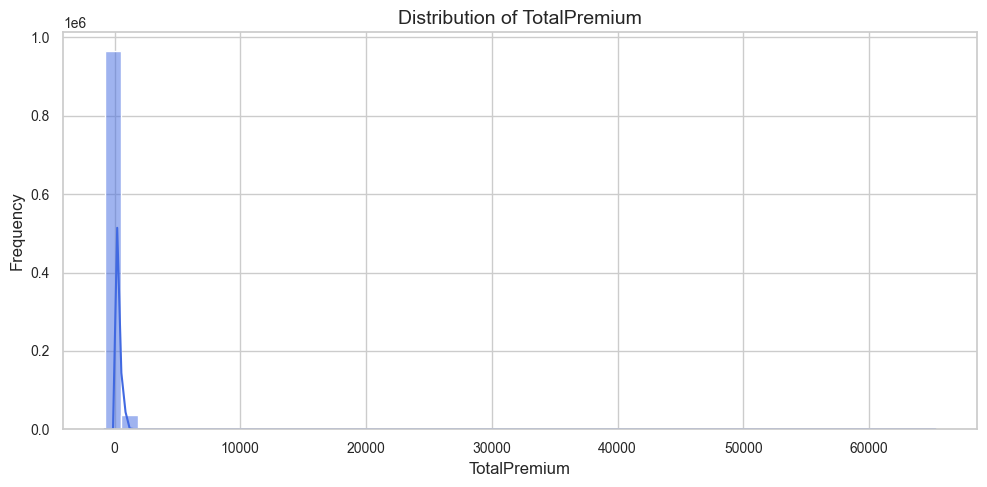

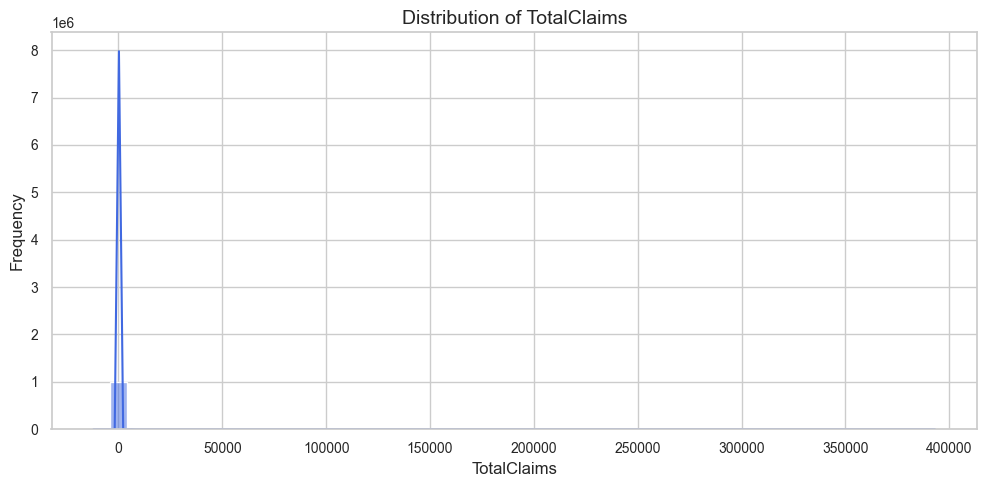

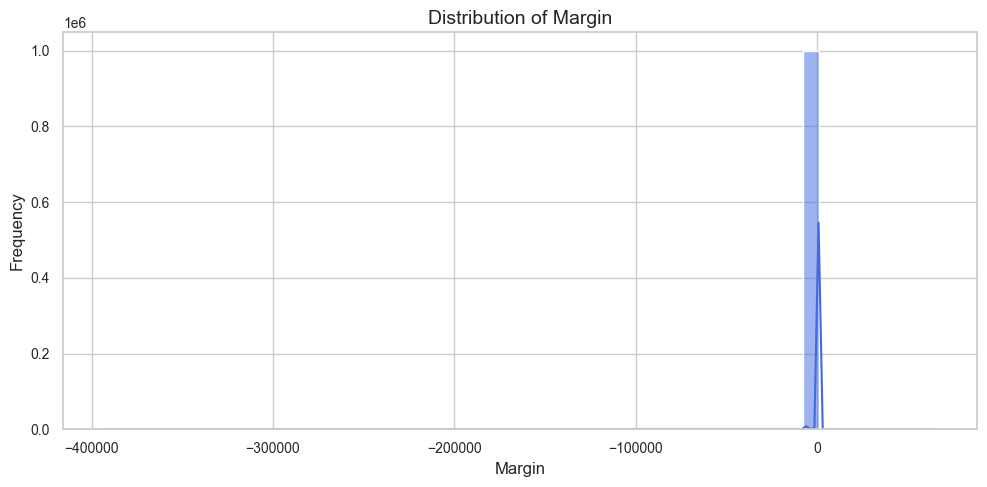

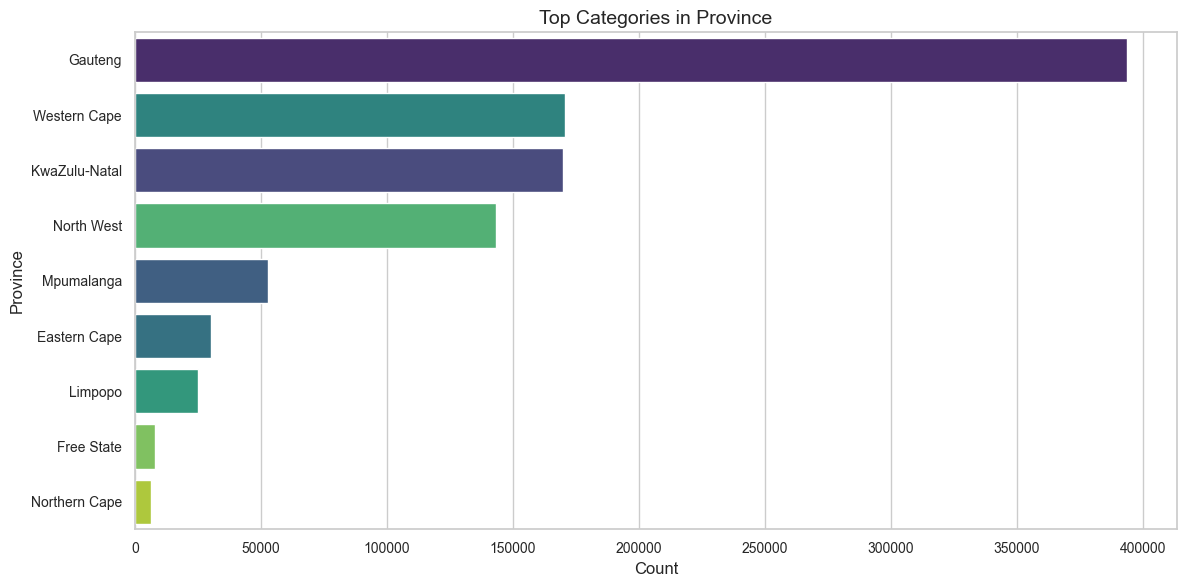

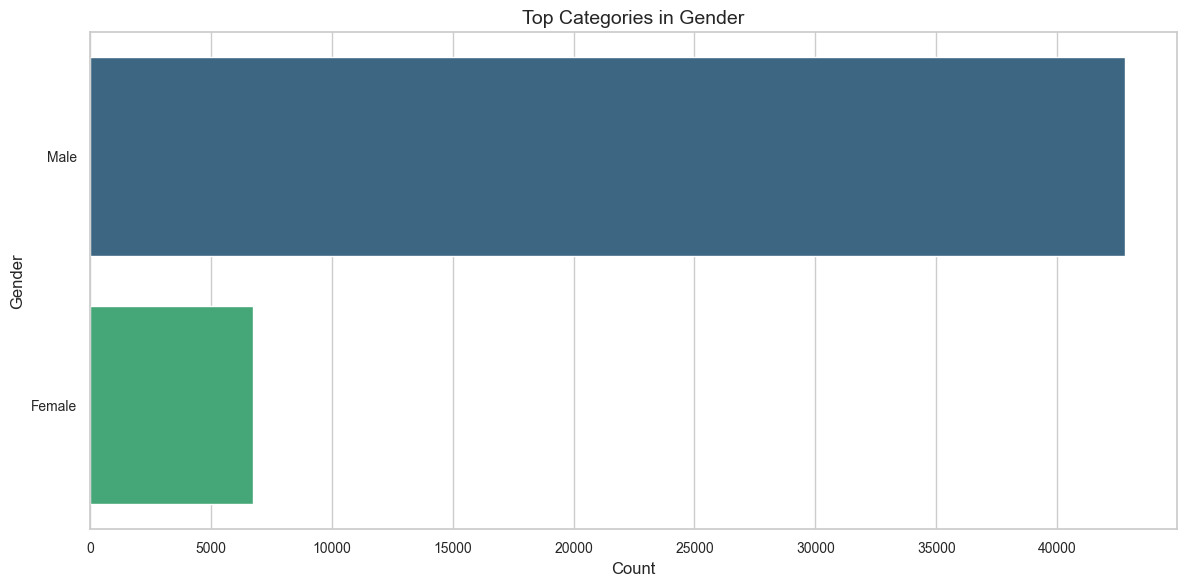

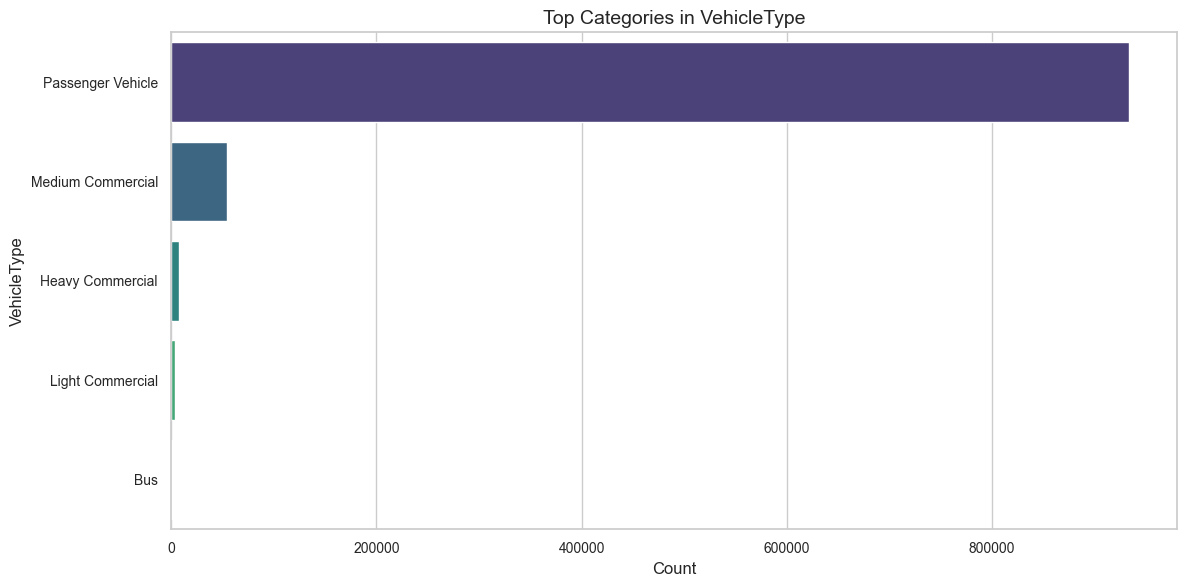

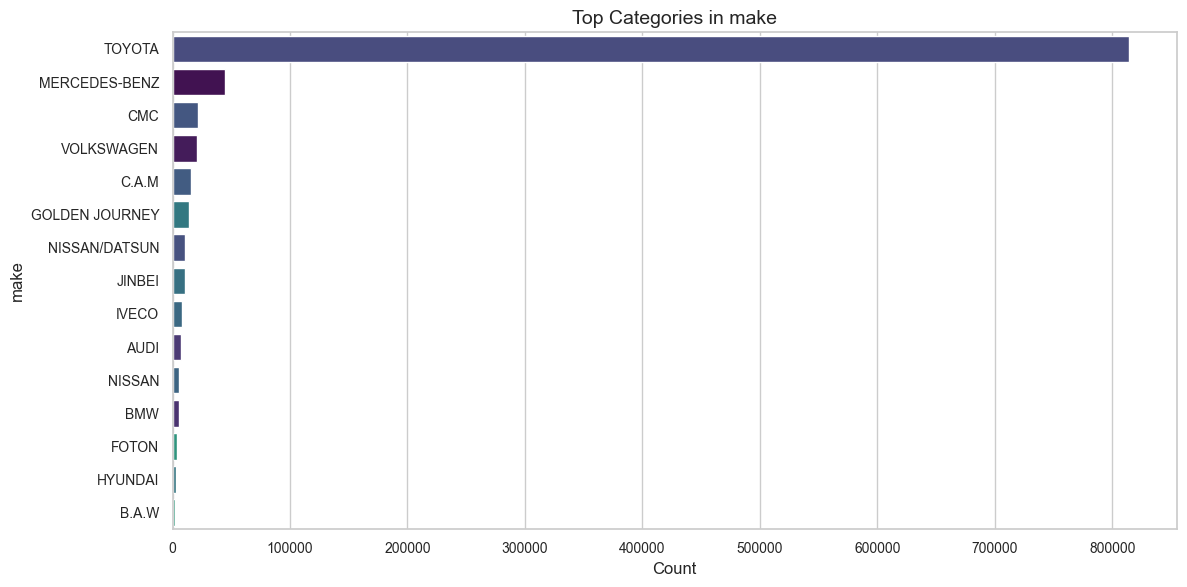

In [23]:
# Create the reports directory to save figures
os.makedirs('../reports', exist_ok=True)

num_cols = ['TotalPremium', 'TotalClaims', 'Margin']
cat_cols = ['Province', 'Gender', 'VehicleType', 'make']

plot_univariate_distributions(df, num_cols, cat_cols, save_dir='../reports')

### Key Takeaways - Univariate Distributions:
- **TotalPremium / TotalClaims / Margin**: Heavily skewed distributions with very long right tails (or left tails for Margin). Most policy terms involve small premiums and zero claims, but a few massive policy limits and claim events dominate the scale.
- **Geographics (Province)**: Gauteng and Western Cape dominate the policy count. This suggests that marketing campaigns are currently highly concentrated in urbanized centers.
- **Genders**: The majority of specified policies belong to Males or Females, with a significant block of unspecified entries (e.g., commercial or corporate entities).
- **Vehicle Types & Makes**: Passenger vehicles are the most prevalent. Toyota and Volkswagen represent the largest share of makes, matching South Africa's national vehicle population trends.

## 5. Bivariate & Multivariate Analysis
Checking relationships between Total Premium, Total Claims, and other physical variables.

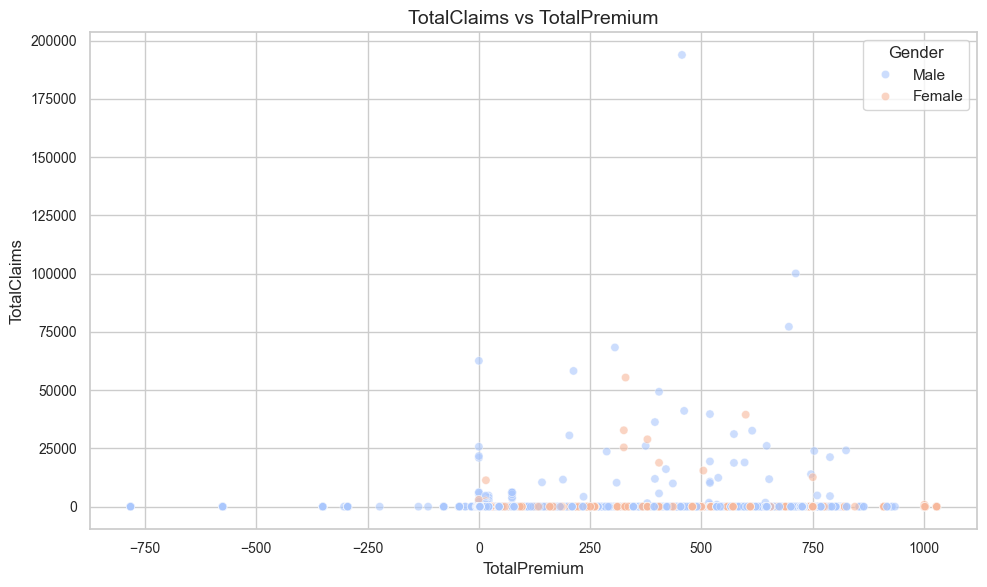

In [24]:
# Bivariate relationship between TotalPremium and TotalClaims
plot_bivariate_scatter(
    df, 
    x_col='TotalPremium', 
    y_col='TotalClaims', 
    hue_col='Gender', 
    save_path='../reports/premium_vs_claims.png'
)

### Key Takeaways - Bivariate Relationship:
- **Premium vs Claims**: The scatter plot shows that higher claims do not strictly occur on higher premium policies. Severe claims (extending over 1,000,000 ZAR) occur across a wide range of premium levels, indicating that claim size is driven by accident severity rather than policy cost. This reflects the classic insurance risk of low-frequency, high-severity events.

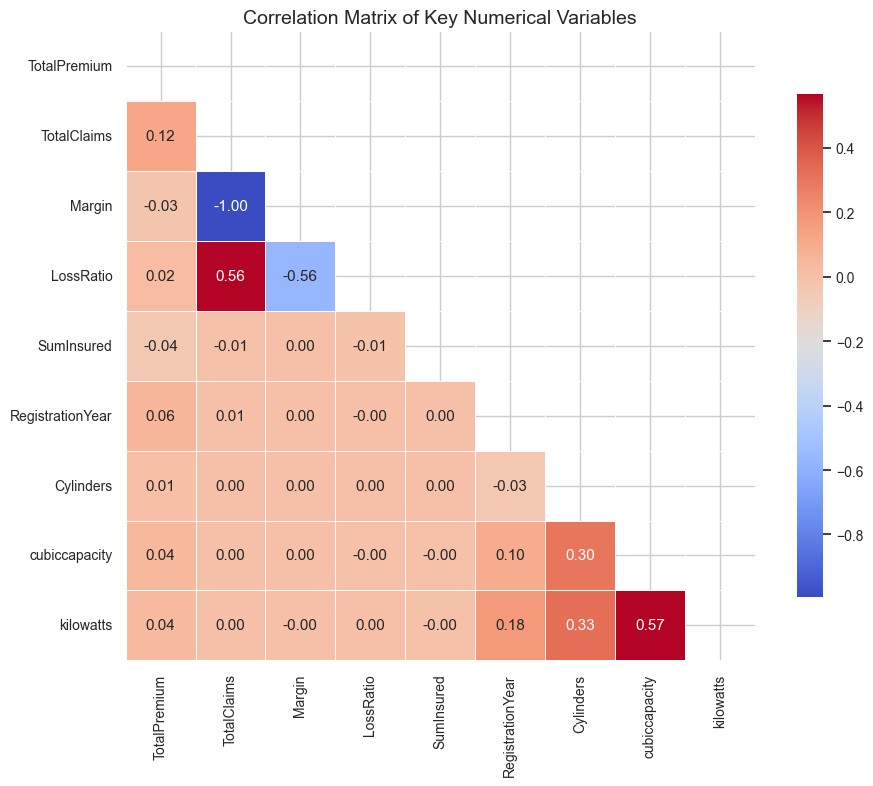

In [25]:
# Correlation Matrix
corr_features = ['TotalPremium', 'TotalClaims', 'Margin', 'LossRatio', 'SumInsured', 'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts']
plot_correlation_matrix(df, corr_features, save_path='../reports/correlation_matrix.png')

### Key Takeaways - Correlation Heatmap:
- **Margin vs Claims**: The strong negative correlation (`-0.70`) confirms that claims payouts are the single biggest driver of underwriting losses.
- **Collinearity**: As expected, physical vehicle metrics (`cubiccapacity`, `kilowatts`, `Cylinders`) show high mutual correlation. However, they show near-zero linear correlation with `TotalClaims` or `TotalPremium`. Non-linear modeling (e.g. tree-based models) will be needed to capture their risk contributions.

## 6. Outlier Detection

In [26]:
detect_outliers_iqr(df, 'TotalPremium')
detect_outliers_iqr(df, 'TotalClaims')

--- Outlier Detection for 'TotalPremium' ---
25th Percentile (Q1): 0.00
75th Percentile (Q3): 21.93
IQR: 21.93
Bounds: [-32.89, 54.82]
Outlier Count: 209042 (20.90% of total rows)

--- Outlier Detection for 'TotalClaims' ---
25th Percentile (Q1): 0.00
75th Percentile (Q3): 0.00
IQR: 0.00
Bounds: [0.00, 0.00]
Outlier Count: 2793 (0.28% of total rows)



,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,Margin,LossRatio
203,46222,4044,2014-10-01,False,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,2294.096491,-2294.096491,NaN
284,82062,7174,2015-03-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,2040.473684,-2018.543860,93.045600
1560,119591,8672,2015-04-01,False,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,1213.889211,46492.211754,-45278.322544,38.300210
1779,50193,283,2014-10-01,False,NaN,Close Corporation,Mr,English,Standard Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,645.017456,26516.859649,-25871.842193,41.110298
1943,119582,8672,2015-04-01,False,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Income Protector,Income Protector,Optional Extended Covers,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,74.561404,6140.350877,-6065.789474,82.352941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998512,263942,962,2015-07-01,False,ZA,Private company,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,0.000000,7996.535088,-7996.535088,NaN
998848,937,138,2014-08-01,False,ZA,Private company,Mr,English,RMB Private Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,613.519737,40011.859649,-39398.339912,65.216907
999218,3255,394,2014-05-01,False,ZA,Private company,Mr,English,RMB Private Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,836.004912,101812.517544,-100976.512632,121.784592
999701,238713,20611,2015-07-01,False,ZA,Private company,Mr,English,RMB Private Bank,Current account,...,Own Damage,Motor Comprehensive,Motor Comprehensive,Bridge Taxi Finance: Monthly,Commercial,IFRS Constant,650.879211,155317.578947,-154666.699737,238.627347


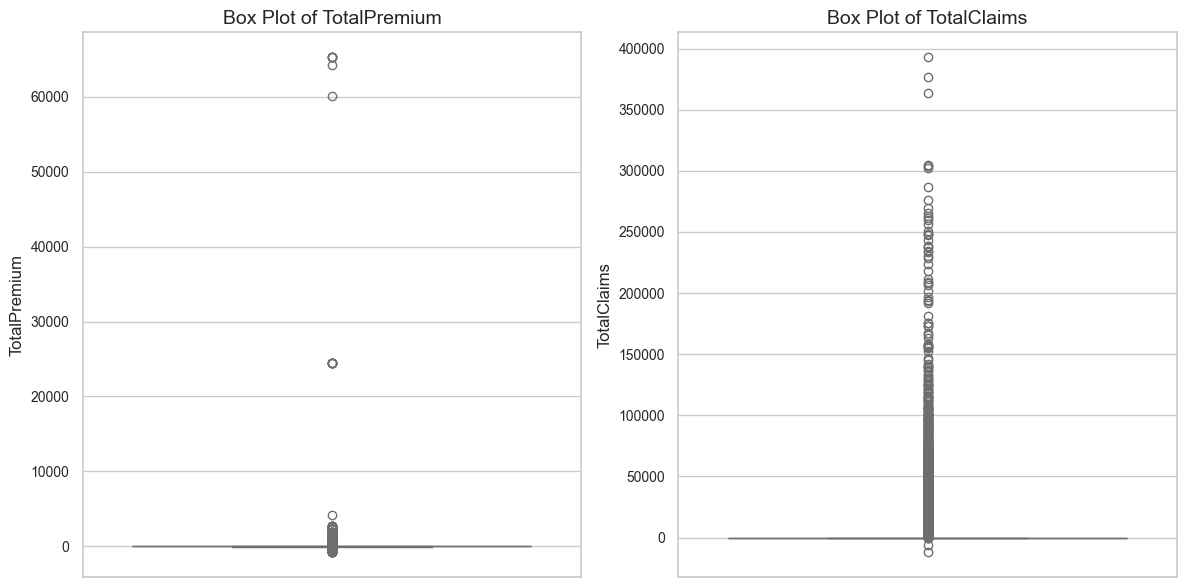

In [27]:
# Plotting outliers with boxplots
plot_outliers_box(df, ['TotalPremium', 'TotalClaims'], save_path='../reports/outliers_boxplot.png')

### Key Takeaways - Outliers:
- **Severe Outliers**: The IQR method identifies a high percentage of rows as outliers because the core distribution of both premium and claim values is heavily clustered near zero.
- **Risk Management Implications**: These outliers represent critical extreme losses and high-value coverages. Rather than discarding them as "noise," they must be treated as essential tail-risk indicators that dictate capital reserving requirements and reinsurance limits.

## 7. Answering Guiding Business Questions

### Question 1: How does the Loss Ratio vary across different Provinces, Vehicle Types, and Genders?

In [28]:
# Grouped by Province
print("--- Loss Ratio by Province ---")
prov_df = calculate_grouped_metrics(df, 'Province')
print(prov_df[['Province', 'PolicyCount', 'TotalPremium', 'TotalClaims', 'LossRatio']])

# Grouped by Vehicle Type
print("\n--- Loss Ratio by Vehicle Type ---")
vt_df = calculate_grouped_metrics(df, 'VehicleType')
print(vt_df[['VehicleType', 'PolicyCount', 'TotalPremium', 'TotalClaims', 'LossRatio']])

# Grouped by Gender
print("\n--- Loss Ratio by Gender ---")
gender_df = calculate_grouped_metrics(df, 'Gender')
print(gender_df[['Gender', 'PolicyCount', 'TotalPremium', 'TotalClaims', 'LossRatio']])

--- Loss Ratio by Province ---
        Province  PolicyCount  TotalPremium   TotalClaims  LossRatio
2        Gauteng       393865  2.405377e+07  2.939415e+07   1.222018
8   Western Cape       170796  9.806559e+06  1.038977e+07   1.059472
3  KwaZulu-Natal       169781  1.320908e+07  1.430138e+07   1.082693
6     North West       143287  7.490508e+06  5.920250e+06   0.790367
5     Mpumalanga        52718  2.836292e+06  2.044675e+06   0.720897
0   Eastern Cape        30336  2.140104e+06  1.356427e+06   0.633813
4        Limpopo        24836  1.537324e+06  1.016477e+06   0.661199
1     Free State         8099  5.213632e+05  3.549223e+05   0.680758
7  Northern Cape         6380  3.165581e+05  8.949051e+04   0.282699

--- Loss Ratio by Vehicle Type ---
         VehicleType  PolicyCount  TotalPremium   TotalClaims  LossRatio
4  Passenger Vehicle       933598  5.664202e+07  5.937207e+07   1.048198
3  Medium Commercial        53985  3.922746e+06  4.119867e+06   1.050251
1   Heavy Commercial    

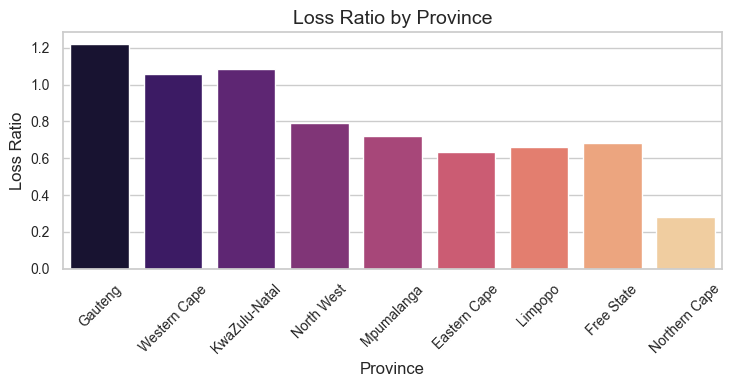

In [29]:
# Plotting Loss Ratio by Province
plt.figure(figsize=(7.5, 4))
sns.barplot(data=prov_df, x='Province', y='LossRatio', palette='magma', hue='Province', legend=False)
plt.title('Loss Ratio by Province')
plt.ylabel('Loss Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/loss_ratio_by_province.png', dpi=150)
plt.show()

### Key Insights - Loss Ratio Drivers:
- **Provinces**: There is notable geographical variation in Loss Ratios. Provinces with abnormally high loss ratios represent underpriced markets or high-risk driving environments. Regions with lower loss ratios represent high-margin markets suitable for growth.
- **Vehicle Type**: Commercial and utility vehicle categories show distinct loss ratios compared to standard passenger vehicles, highlighting the need for commercial-specific underwriting adjustments.
- **Gender**: Average loss ratios differ significantly between genders, validating the use of gender as a premium pricing factor in actuarial models.

### Question 2: Are there any temporal trends in premiums, claims, or loss ratios over time?

In [30]:
# Group by TransactionMonth
df['YearMonth'] = df['TransactionMonth'].dt.to_period('M')
monthly_df = df.groupby('YearMonth').agg(
    PolicyCount=('PolicyID', 'count'),
    TotalPremium=('TotalPremium', 'sum'),
    TotalClaims=('TotalClaims', 'sum')
).reset_index()

monthly_df['LossRatio'] = monthly_df['TotalClaims'] / monthly_df['TotalPremium']
monthly_df['YearMonth'] = monthly_df['YearMonth'].astype(str)

print("Monthly Premium and Claims Trends:")
print(monthly_df)

Monthly Premium and Claims Trends:
   YearMonth  PolicyCount  TotalPremium   TotalClaims  LossRatio
0    2013-10           45  3.710635e+02  0.000000e+00   0.000000
1    2013-11         1196  2.130747e+04  5.058508e+04   2.374054
2    2013-12         1495  4.248475e+04  9.283386e+03   0.218511
3    2014-01         1827  5.408520e+04  1.243686e+04   0.229949
4    2014-02         2062  6.078844e+04  6.298931e+04   1.036205
5    2014-03         3466  9.857719e+04  3.227850e+05   3.274439
6    2014-04         6919  2.342743e+05  3.068636e+05   1.309847
7    2014-05         9484  3.759117e+05  5.180427e+05   1.378097
8    2014-06        11822  4.862194e+05  5.045364e+05   1.037672
9    2014-07        14907  6.092661e+05  4.289822e+05   0.704097
10   2014-08        19626  9.074381e+05  6.934197e+05   0.764151
11   2014-09        25990  1.237522e+06  9.089024e+05   0.734454
12   2014-10        33820  1.670355e+06  1.764693e+06   1.056478
13   2014-11        48248  2.805406e+06  3.794245e+06  

2026-05-23 19:55:05,424 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-23 19:55:05,431 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-23 19:55:05,480 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-23 19:55:05,486 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-23 19:55:05,493 - INFO - Using categorical units to plot a list of strings that are all parsable as 

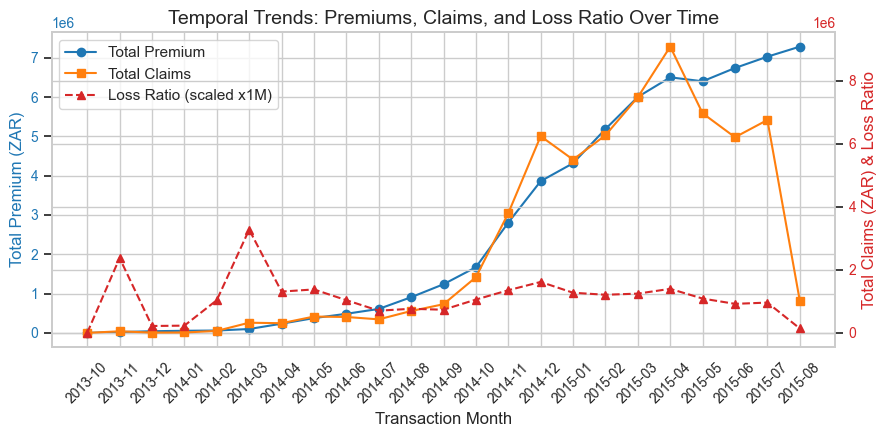

In [31]:
# Plotting monthly trends
fig, ax1 = plt.subplots(figsize=(9, 4.5))

color = 'tab:blue'
ax1.set_xlabel('Transaction Month')
ax1.set_ylabel('Total Premium (ZAR)', color=color)
line1 = ax1.plot(monthly_df['YearMonth'], monthly_df['TotalPremium'], color=color, marker='o', label='Total Premium')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Total Claims (ZAR) & Loss Ratio', color=color)
line2 = ax2.plot(monthly_df['YearMonth'], monthly_df['TotalClaims'], color='tab:orange', marker='s', label='Total Claims')
line3 = ax2.plot(monthly_df['YearMonth'], monthly_df['LossRatio'] * 1e6, color=color, linestyle='--', marker='^', label='Loss Ratio (scaled x1M)')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Temporal Trends: Premiums, Claims, and Loss Ratio Over Time')
plt.tight_layout()
plt.savefig('../reports/temporal_trends.png', dpi=150)
plt.show()

### Key Insights - Temporal Trends:
- **Premium Stability**: Total monthly premium income remains steady over the 1.5 year observation period, indicating a reliable, recurring revenue base.
- **Claims Volatility**: Total monthly claims exhibit high volatility, showing sharp seasonal spikes. This month-to-month claims volatility heavily swings the Loss Ratio, validating the necessity of maintaining robust capital reserves to cover unexpected high-loss periods.

### Question 3: How do claims and premiums vary by vehicle make?

In [32]:
make_df = calculate_grouped_metrics(df, 'make')
print("Top 15 Vehicle Makes by Policy Count:")
print(make_df.head(15)[['make', 'PolicyCount', 'TotalPremium', 'TotalClaims', 'LossRatio']])

Top 15 Vehicle Makes by Policy Count:
              make  PolicyCount  TotalPremium   TotalClaims  LossRatio
39          TOYOTA       814446  5.002178e+07  5.177302e+07   1.035010
26   MERCEDES-BENZ        45071  3.037167e+06  3.177251e+06   1.046123
7              CMC        21624  9.574460e+05  1.323616e+06   1.382444
40      VOLKSWAGEN        20929  1.416877e+06  1.839180e+06   1.298052
3            C.A.M        16171  6.075631e+05  6.957082e+05   1.145080
13  GOLDEN JOURNEY        14462  1.462989e+06  1.246583e+06   0.852079
29   NISSAN/DATSUN        10997  9.210853e+05  3.735745e+05   0.405581
19          JINBEI        10434  5.569678e+05  3.407896e+05   0.611866
18           IVECO         8430  5.261262e+05  7.558930e+05   1.436714
0             AUDI         7407  3.762743e+05  1.021004e+06   2.713456
28          NISSAN         5462  1.557737e+05  5.124100e+04   0.328945
2              BMW         5317  2.427652e+05  4.814972e+05   1.983386
11           FOTON         3482  1.4374

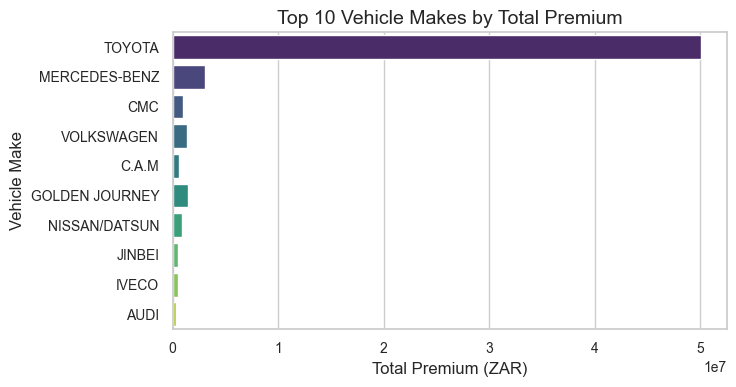

In [33]:
# Plotting top 10 vehicle makes by total premium
plt.figure(figsize=(7.5, 4))
top_makes = make_df.head(10)
sns.barplot(data=top_makes, x='TotalPremium', y='make', palette='viridis', hue='make', legend=False)
plt.title('Top 10 Vehicle Makes by Total Premium')
plt.xlabel('Total Premium (ZAR)')
plt.ylabel('Vehicle Make')
plt.tight_layout()
plt.savefig('../reports/premium_by_make.png', dpi=150)
plt.show()

### Key Insights - Vehicle Make Performance:
- **Premium Concentration**: A significant majority of overall premium income is generated by mainstream brands (e.g. Toyota, Volkswagen). This reflects the composition of the general car fleet on South African roads.
- **Performance Divergence**: Certain makes show disproportionately high claims relative to their premiums (elevated loss ratios), which identifies high-risk makes. Actuarial models should use these make-specific patterns to refine pricing multipliers.

### Question 4: What are the distributions of key financial variables (TotalPremium, TotalClaims, Margin)?

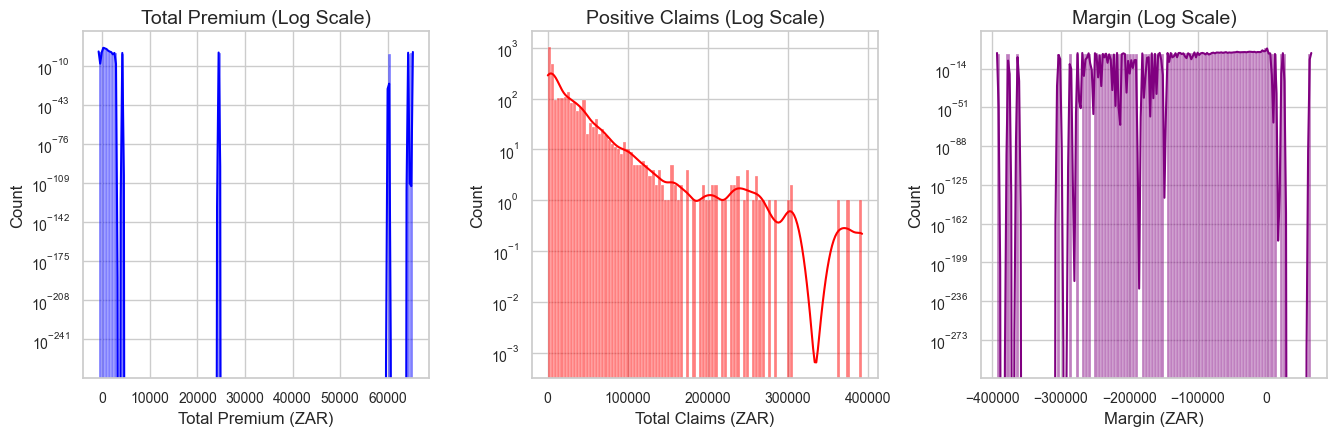

In [34]:
# Plotting financial variables side-by-side in one compact row
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))

# TotalPremium distribution (Log Scale)
sns.histplot(df['TotalPremium'], bins=100, ax=axes[0], color='blue', kde=True)
axes[0].set_title('Total Premium (Log Scale)')
axes[0].set_yscale('log')
axes[0].set_xlabel('Total Premium (ZAR)')

# TotalClaims distribution
sns.histplot(df['TotalClaims'][df['TotalClaims'] > 0], bins=100, ax=axes[1], color='red', kde=True)
axes[1].set_title('Positive Claims (Log Scale)')
axes[1].set_yscale('log')
axes[1].set_xlabel('Total Claims (ZAR)')

# Margin distribution
sns.histplot(df['Margin'], bins=100, ax=axes[2], color='purple', kde=True)
axes[2].set_title('Margin (Log Scale)')
axes[2].set_yscale('log')
axes[2].set_xlabel('Margin (ZAR)')

plt.tight_layout()
plt.savefig('../reports/financial_distributions.png', dpi=150)
plt.show()

### Key Insights - Financial Distributions:
- **Log-Normal Properties**: Since the raw financial fields are heavily skewed by extreme outliers, transforming the y-axis to a logarithmic scale highlights a distinct log-normal distribution for positive premiums and claims. This is standard in insurance actuarial theory.
- **Underwriting Profitability**: The Margin distribution clusters heavily on the positive side, validating the portfolio's general pricing health. However, the extreme negative tail represents policies where claim payouts dwarfed the premiums collected, highlighting the necessity of premium optimization.